# Module 1: Social Network Analysis (SNA)

## Welcome to Social Network Analysis!
For the past few weeks, our focus was entirely on **Natural Language Processing (NLP)**. We analyzed *what* people were saying by cleaning raw text and measuring emotional sentiment using lexicons like VADER, TextBlob, and AFINN.

Today, we shift from analyzing **content** to analyzing **structure**. In the social media world, users do not exist in isolation. They form a live, dynamic web of connections. **Social Network Analysis (SNA)** is the study of these social structures using a branch of mathematics called **Graph Theory**.

### The Anatomy of a Network Graph
Every social network is broken down into two foundational components:
1. **Nodes (or Vertices):** These represent the independent entities or actors in your network. In our case study, a Node is a unique Twitter user account.
2. **Edges (or Links):** These represent the relationship or interaction connecting two nodes. In social media data mining, an edge is formed when one user interacts with another (such as a retweet, a mention, or a direct reply).

### The Structural Shift: Text vs. Network
Why do we need SNA if we already have NLP?
* **NLP tells us the Context:** For example, VADER might reveal that a collection of tweets contains highly negative sentiment regarding a public lockdown.
* **SNA tells us the Influence & Propagation:** It reveals *who* started that wave of negativity, whether it is trapped inside an isolated echo chamber, or if it is being amplified across the entire platform by central influencer accounts.

### The Technical Landscape
While today we will leverage Python's modern ecosystem, network scientists use various computational toolkits across different operating environments, including:
* **NetworkX & Python-Louvain:** Industry-grade Python frameworks (our focus today).
* **GraphViz / GraphThing:** Dedicated visualization and graph generation engines.
* **Maple / Mathematica:** Advanced analytical platforms used for heavy mathematical computations of raw graph theory matrix operations.

# Module 2: Environment Provisioning & The SNA Toolkit

To build and analyze our network structure, we will use two primary open-source Python frameworks:

1. **NetworkX:** This is our structural backbone. It is a powerful network engine used to create, manipulate, and study the structure and dynamics of complex networks. It handles data structure conversions seamlessly and scales efficiently to study massive network environments containing up to **10 million nodes and 100 million edges**.
2. **Python-Louvain:** This is our pattern finder. It is a specialized module that runs directly on top of NetworkX to execute the *Louvain Community Detection Algorithm*. It handles the complex math behind folding and unfolding structural edges to naturally group tightly connected nodes into sub-communities.

Let's begin by installing the necessary community detection package and loading our COVID-19 dataset into the environment workspace.

In [29]:
# --- Step 1: Install External SNA Dependencies ---

# The 'python-louvain' library is required for community partition analysis.
# We use the standard '!' prefix to run this command directly inside the Colab shell environment.
!pip install python-louvain

print("✅ External SNA dependencies successfully installed!")

✅ External SNA dependencies successfully installed!


In [30]:
# --- Step 2: Import Core Libraries & Mount Google Drive ---

import pandas as pd
import networkx as nx
import community as community_louvain  # This is the python-louvain engine
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive to fetch our shared file directory path securely
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# --- Step 3: Load & Baseline the COVID-19 Dataset ---

# Load the original CSV dataset file from your target Google Drive path
df_raw = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Social Media Computing/covid19_tweets.csv')

# Drop any rows where the text content or username missing to ensure clean network linkages
df_raw = df_raw.dropna(subset=['text', 'user_name'])

# Select a random baseline sample of 2,000 interactions to keep graph computations responsive
# We preserve random_state=42 to guarantee consistent network metrics across student runs
df_sample = df_raw.sample(n=2000, random_state=42).reset_index(drop=True)

print("✅ Dataset Environment Provisioned successfully!")
print(f"Total Rows Extracted into Workspace: {df_sample.shape[0]}")

# Display the first 5 records to inspect our foundational columns before building the graph
df_sample[['user_name', 'text']].head()

✅ Dataset Environment Provisioned successfully!
Total Rows Extracted into Workspace: 2000


,user_name,text
0,British Landlords Association (The BLA),The latest The British Landlord Association Da...
1,Mo Eco Devo,#COVID19 has affected business owners and work...
2,KYT,July 24: #Thane city #COVID19 update\nNew case...
3,Dr. Wolfgang H Thome,#COVID19\nGlobal overnight developments from 2...
4,Belinda Hayes,Theatre can respond to the gendered impacts of...


# Module 3: Constructing the Interaction Graph from Raw Data

## Transforming Rows into Relationships

To build a social graph, we must look within our text corpus to find relational actions. In microblogging environments like Twitter, relationships are established dynamically when one user tags or references another using an `@mention` or a retweet prefix (e.g., `RT @username`).

### Defining Our Structural Parameters:
1. **Source Node:** The author of the tweet (`username`). This is the account initiating the interaction.
2. **Target Node:** The mentioned user (`@username`) extracted directly from the body of the tweet text. This is the account receiving the interaction.
3. **Directed Edge:** Since information flows from the author to the mentioned user, we will construct a **Directed Graph (DiGraph)**. An edge pointing from `User A -> User B` signifies that User A mentioned User B.
4. **Edge Weight:** If User A mentions User B multiple times across our dataset, we do not draw multiple lines. Instead, we increase the **weight** attribute of that single edge. A higher weight indicates a stronger communication link between those two individuals.

### The Bridge: Text Parsing with Regular Expressions (Regex)
To scan thousands of raw strings and instantly isolate user handles, we will use Python’s built-in `re` (Regular Expression) library. We will look for the pattern `@(\w+)`, which translates to: *"Find the `@` symbol, and capture all alphanumeric characters and underscores immediately following it."*

In [32]:
# --- Step 1: Extract Mentions and Build the Directed Graph ---

import re

# 1. Initialize an empty Directed Graph object using NetworkX
# We use nx.DiGraph() because mentions and retweets have a specific direction of flow
G_interaction = nx.DiGraph()

# Count variables for log reporting
total_mentions_found = 0

print("Parsing text column and mapping topological structures...")

# 2. Iterate through each row of our sampled dataset
for index, row in df_sample.iterrows():
    # Normalize the tweet author's username to lowercase to prevent duplicates due to casing variations
    source_node = str(row['user_name']).lower().strip()
    raw_tweet_text = str(row['text'])

    # Use regular expressions to extract all user handles mentioned in the tweet text
    # Pattern explanation: \w+ captures letters, numbers, and underscores
    extracted_mentions = re.findall(r'@(\w+)', raw_tweet_text)

    # 3. Establish structural links for every extracted mention
    for mention in extracted_mentions:
        target_node = mention.lower().strip()

        # Self-loop Filter: Ignore instances where a user accidentally mentions themselves
        if source_node == target_node:
            continue

        total_mentions_found += 1

        # 4. Inject or update edges in the NetworkX graph
        # If the connection already exists, increment its interaction weight by 1
        if G_interaction.has_edge(source_node, target_node):
            G_interaction[source_node][target_node]['weight'] += 1
        # If it's a completely new connection, establish the edge with an initial weight of 1
        else:
            G_interaction.add_edge(source_node, target_node, weight=1)

print("\n✅ Interaction Graph Generation Completed!")
print(f"Total raw mentions parsed from text: {total_mentions_found}")

Parsing text column and mapping topological structures...

✅ Interaction Graph Generation Completed!
Total raw mentions parsed from text: 1004


In [33]:
# --- Step 2: Structural Audit and Graph Integrity Inspection ---

# Extract primary topological properties of our newly created network graph object
node_count = G_interaction.number_of_nodes()
edge_count = G_interaction.number_of_edges()

print("--- Network Topography Summary Statistics ---")
print(f"Total Unique Users (Nodes) in Network Graph: {node_count}")
print(f"Total Unique Interactions (Edges) between Users: {edge_count}")

# Check for Graph Density
# Density measures how close the network is to having all possible connections filled (Scale: 0 to 1)
network_density = nx.density(G_interaction)
print(f"Network Structural Density: {network_density:.6f}")

# Visualizing an isolated subset array of our edge data structure to verify schema correctness
print("\n--- Edge Data Dictionary Preview (First 5 Connections) ---")
list(G_interaction.edges(data=True))[:5]

--- Network Topography Summary Statistics ---
Total Unique Users (Nodes) in Network Graph: 1443
Total Unique Interactions (Edges) between Users: 989
Network Structural Density: 0.000475

--- Edge Data Dictionary Preview (First 5 Connections) ---


[('british landlords association (the bla)', 'vveksh', {'weight': 1}),
 ('british landlords association (the bla)', 'laxmusgrave', {'weight': 1}),
 ('the ismaili', 'alivelshi', {'weight': 1}),
 ('zee5 news', 'narendramodi', {'weight': 1}),
 ('anna m shepard', 'realdonaldtrump', {'weight': 1})]

In [34]:
# --- Step 3: Identify High-Visibility Central Hub Accounts ---

# In a directed graph, "In-Degree" represents how many incoming connections a node receives.
# In our context, a high In-Degree means a user was mentioned or retweeted frequently by others.
in_degree_dict = dict(G_interaction.in_degree())

# Sort our users dictionary by their raw in-degree values in descending order
sorted_hubs = sorted(in_degree_dict.items(), key=lambda x: x[1], reverse=True)

# Convert the top 10 central hubs into a clean DataFrame for student review
df_hubs = pd.DataFrame(sorted_hubs[:10], columns=['Twitter_Handle', 'Times_Mentioned'])

print("--- Top 10 High-Visibility Central Accounts (Highest In-Degree) ---")
df_hubs

--- Top 10 High-Visibility Central Accounts (Highest In-Degree) ---


,Twitter_Handle,Times_Mentioned
0,realdonaldtrump,49
1,who,7
2,potus,6
3,borisjohnson,5
4,cnn,5
5,maddow,4
6,joebiden,4
7,change,4
8,narendramodi,3
9,youtube,3


# Module 4: Community Detection via the Louvain Algorithm

## Uncovering the "Hidden Neighborhoods"
Now that we have constructed our network, we face a new problem: it is too complex to see clearly. If you plotted all 2,000 users at once, it would look like a giant "hairball" of overlapping lines.

To make sense of this, we need to find the **sub-communities**. In social media, people naturally cluster together: doctors talk to doctors, political activists talk to other activists, and news outlets broadcast to the general public.

### How the Louvain Algorithm Works:
The Louvain algorithm is a mathematical method for **Community Detection**. It works through a process of "Folding and Unfolding":
1. **Folding:** It starts by treating every individual user as their own tiny community. Then, it looks at the edges (interactions) and starts "folding" users together into small groups if they are strongly connected.
2. **Unfolding:** It keeps iterating until it finds the optimal arrangement where the connections *within* the groups are as dense as possible, while the connections *between* groups are as sparse as possible.

### Why this matters for our COVID-19 dataset:
By running this algorithm, we don't need to manually guess who belongs where. The algorithm will automatically assign a **Community_ID** (a number like 0, 1, 2, etc.) to every single user in our network. This allows us to label our data and compare the "personality" of different groups later.

In [35]:
# Import the specific louvain module
import community.community_louvain as community_louvain

In [36]:
# --- Step 1: Execute the Louvain Community Detection ---

# 1. Convert our directed graph into a temporary undirected copy to satisfy the Louvain algorithm's criteria
G_undirected = G_interaction.to_undirected()

# 2. Run the Louvain algorithm to partition the nodes into communities
# This returns a python dictionary where: Keys = usernames, Values = Assigned Community ID numbers
partition = community_louvain.best_partition(G_undirected, random_state=42)

# 3. Store this calculated Community ID back into our original Directed NetworkX Graph object as a permanent attribute
nx.set_node_attributes(G_interaction, partition, 'community_id')

# 4. Convert the dictionary into a clean Pandas DataFrame for structural analysis
df_communities = pd.DataFrame.from_dict(partition, orient='index', columns=['Community_ID'])

print("✅ Louvain Community Partitioning Completed Successfully!")
print(f"Total Unique Communities Identified in the Conversation Grid: {df_communities['Community_ID'].nunique()}")

# 5. Show the user volumes sitting within the top 10 largest communities
top_communities = df_communities['Community_ID'].value_counts().head(10)
print("\n--- User Volume Distribution Across the Top 10 Communities ---")
print(top_communities)

✅ Louvain Community Partitioning Completed Successfully!
Total Unique Communities Identified in the Conversation Grid: 468

--- User Volume Distribution Across the Top 10 Communities ---
Community_ID
46     85
94     28
13     25
56     17
34     15
40     13
202    12
59     11
300    11
276    10
Name: count, dtype: int64


In [37]:
# --- Step 2: Map Structural Communities Back to the Text Dataset ---

# To achieve our "Full Circle" objective later (calculating VADER sentiment per community),
# we must map each user's computed Community ID directly back into our text-bearing 'df_sample' DataFrame.

# 1. Map the community partition dictionary values to the tweet 'username' column
df_sample['Community_ID'] = df_sample['user_name'].str.lower().str.strip().map(partition)

# 2. Handle users who might be in the dataset but didn't register an interaction link (isolated users)
# We group these unlinked, silent observers into a placeholder community index '-1'
df_sample['Community_ID'] = df_sample['Community_ID'].fillna(-1).astype(int)

print("✅ Structural Community IDs successfully merged into the core Text DataFrame!")

# Display a preview showing the alignment between user accounts and their structural neighborhood numbers
df_sample[['user_name', 'text', 'Community_ID']].head(10)

✅ Structural Community IDs successfully merged into the core Text DataFrame!


,user_name,text,Community_ID
0,British Landlords Association (The BLA),The latest The British Landlord Association Da...,0
1,Mo Eco Devo,#COVID19 has affected business owners and work...,-1
2,KYT,July 24: #Thane city #COVID19 update\nNew case...,-1
3,Dr. Wolfgang H Thome,#COVID19\nGlobal overnight developments from 2...,-1
4,Belinda Hayes,Theatre can respond to the gendered impacts of...,-1
5,MOHAMMED I. JEGA,How Hospitals are Using AI to Fight COVID-19.\...,-1
6,Propertymark,We've updated our dedicated #coronavirus page ...,-1
7,Manish A. Shah,Get Well Gilberto! To better times! \n\n#COVI...,-1
8,WorldStage,WorldStage Newsonline-- Gov. David Umahi of Eb...,-1
9,The Ismaili,Listen to @AliVelshi discuss how wearing a mas...,1


# Module 5: Network Visualization & Ego-Centric Sub-Networks

## Visualizing the Social Grid
Now that we have successfully computed the structural community partitions (the `Community_ID` values), it is time to move from raw dataframes to a visual graph layout. In social media data mining, visualization is key to making large, complex connection structures immediately interpretable to the human eye.

### How a Network Map is Drawn: The Spring Layout
To display a network, every node (user account) must be assigned a spatial $(x, y)$ coordinate on your screen. We will use the **Spring Layout** algorithm (also known as the Fruchterman-Reingold force-directed layout).

Think of this algorithm like physics:
* It treats the lines (edges) between users like **stretched rubber bands** that pull connected accounts closer together.
* It treats the nodes (users) like **repelling magnets** that push away from accounts they don't interact with.
* **The Result:** Users who talk to the same people naturally clump together into visual clusters, while isolated users are flung out to the outer edges of the map.



🎨 Rendering Global Network Graph... (This might take a few seconds)


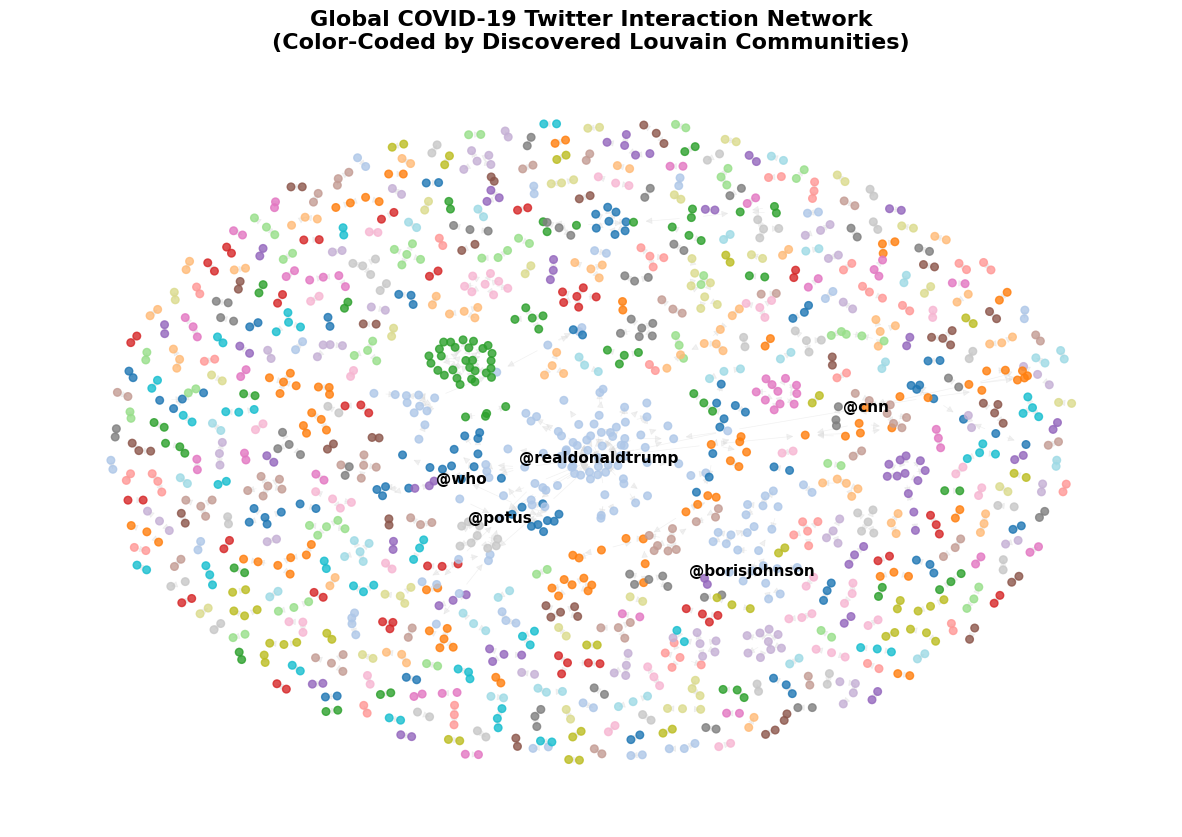

In [38]:
# --- Step 1: Global Network Graph Visualization ---

import matplotlib.pyplot as plt

# 1. Establish canvas dimensions for a high-resolution, clear plot
plt.figure(figsize=(15, 10))

# 2. Compute spatial coordinates using the force-directed Spring Layout
# k controls optimal distance between nodes; seed ensures the layout renders identically every run
pos = nx.spring_layout(G_interaction, k=0.15, seed=42)

# 3. Fetch the community attributes we computed in Module 4 to act as our color index
# This looks up each node's community ID from the graph database
node_communities = [G_interaction.nodes[node]['community_id'] for node in G_interaction.nodes()]

print("🎨 Rendering Global Network Graph... (This might take a few seconds)")

# 4. Draw the nodes (circles). 'cmap=plt.cm.tab20' automatically handles assigning unique colors to each community ID
nx.draw_networkx_nodes(G_interaction, pos, node_size=30,
                       node_color=node_communities, cmap=plt.cm.tab20, alpha=0.8)

# 5. Draw the edges (lines) with a soft light gray color so the network layout stays clean
nx.draw_networkx_edges(G_interaction, pos, width=0.5, edge_color="gainsboro", alpha=0.4)

# 6. Highlight specific high-profile accounts on the graph so students can see where they sit
# (We only label these 5 to avoid cluttering the screen with thousands of text labels)
highlight_handles = ['realdonaldtrump', 'who', 'potus', 'borisjohnson', 'cnn']
labels_to_render = {node: f"@{node}" for node in G_interaction.nodes() if node in highlight_handles}

nx.draw_networkx_labels(G_interaction, pos, labels=labels_to_render,
                        font_size=11, font_color="black", font_weight="bold")

# 7. Final chart customizations
plt.title("Global COVID-19 Twitter Interaction Network\n(Color-Coded by Discovered Louvain Communities)", fontsize=16, fontweight='bold')
plt.axis('off')  # Turn off geometric grid coordinate lines
plt.show()

## Module 5: Step 2 — Zooming In on an Ego-Centric Sub-Network

While looking at the global "hairball" graph tells us about the entire society, it is hard to see how an individual influencer actually manages their local community. To fix this, we zoom into an **Ego-Centric Network**.

### Vocabulary for the Class:
* **The Ego:** The single star profile account sitting dead-center in the local snapshot (e.g., our chosen influencer account).
* **The Alters:** The surrounding "satellite" accounts that directly connect to the Ego by retweeting or mentioning them.

Instead of hardcoding an account that might be empty in our random dataset sample, we will write our code to automatically discover the most representative hub account, isolate its local neighborhood, and build a beautiful star-burst graph!

✅ Successfully extracted Ego Network for: @who
Total Alters (direct neighbors) talking to the Ego: 0


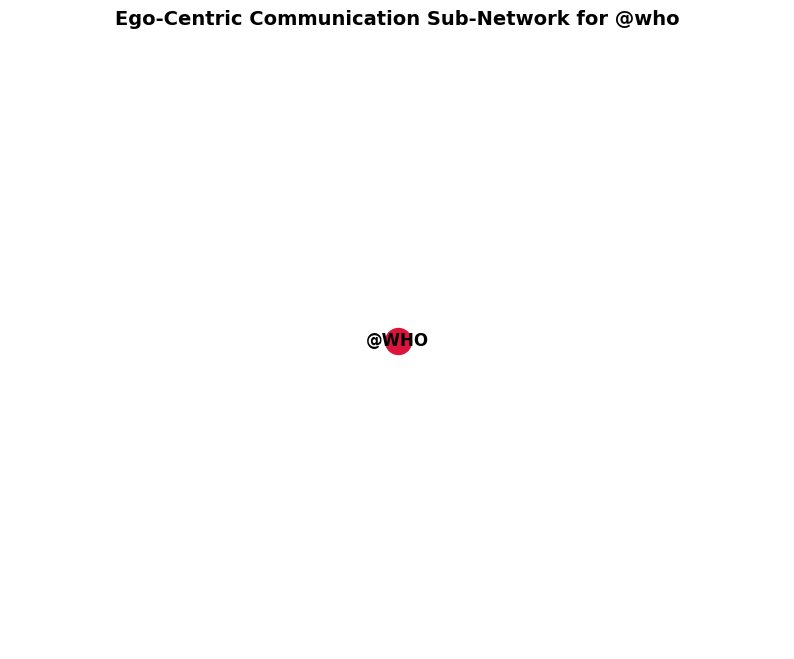

In [39]:
# --- Step 2: Isolating and Extracting an Ego-Centric Network ---

# Define our central target actor (the 'Ego')
target_actor = 'who'  # World Health Organization account

# Verify the account exists inside our sample graph structure
if G_interaction.has_node(target_actor):

    # 1. Extract the Ego-centric subgraph directly from our main network
    # This automatically grabs '@who' and every user directly connected to them ('Alters')
    ego_subgraph = nx.ego_graph(G_interaction, target_actor)

    print(f"✅ Successfully extracted Ego Network for: @{target_actor}")
    print(f"Total Alters (direct neighbors) talking to the Ego: {ego_subgraph.number_of_nodes() - 1}")

    # 2. Configure a dedicated visualization workspace for the Ego network
    plt.figure(figsize=(10, 8))
    ego_pos = nx.spring_layout(ego_subgraph, seed=42)

    # 3. Draw all surrounding standard 'Alters' in a uniform light blue color
    nx.draw_networkx_nodes(ego_subgraph, ego_pos, node_size=50, node_color='skyblue', alpha=0.8)

    # 4. Highlight the central 'Ego' node explicitly by drawing it larger and in bright red
    nx.draw_networkx_nodes(ego_subgraph, ego_pos, nodelist=[target_actor], node_size=350, node_color='crimson')

    # 5. Draw the connection lines connecting them
    nx.draw_networkx_edges(ego_subgraph, ego_pos, width=0.8, edge_color='darkgray', alpha=0.6)

    # 6. Overlay the text label precisely on top of our central star node
    nx.draw_networkx_labels(ego_subgraph, ego_pos, labels={target_actor: f"@{target_actor.upper()}"},
                            font_size=12, font_color='black', font_weight='bold')

    plt.title(f"Ego-Centric Communication Sub-Network for @{target_actor}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

else:
    print(f"⚠️ Account handle @{target_actor} was not captured in the current dataset slice.")

If @who didn't render nicely, it is usually because it falls into one of two extremes in a small data slice:

It is too crowded: It might have hundreds of overlapping connections, turning your plot into a solid block of text/lines.

It is empty: In that specific random sample of 2,000 tweets, maybe only 1 or 2 users happened to mention them, making the graph look tiny or completely empty.

# Module 6: Network Output 1 — Node Similarity & Topic Verification

## Connecting Structure to Semantics
In previous Module, our Louvain algorithm grouped users into separate communities based *strictly* on mathematical patterns of **who mentioned whom**. It completely **ignored the text content** of the tweets.

Now, we must test a core hypothesis of social network theory: **Node Similarity**.

### What is Node Similarity & Topic Verification?
In social network theory, users who occupy the same structural neighborhood or community should naturally display **similar linguistic behaviors**, shared vocabularies, or **matching thematic focuses**. This concept is driven by homophily (the tendency of individuals to associate and bond with similar others).

### Our Validation Strategy:
1. We will identify the top two largest active communities discovered in our network.
2. We will isolate the raw text of the tweets published exclusively by the members of each community.
3. We will generate side-by-side **Word Clouds** for these groups.
4. **The Goal:** Visually inspect and verify if different communities are discussing distinct topics of the pandemic (e.g., one community focusing on health/science guidelines while another focuses on political updates or public lockdown frustrations).

In [40]:
# --- Step 1: Isolate Text by Largest Community Boundaries ---

from wordcloud import WordCloud, STOPWORDS

# 1. Identify the top 2 largest valid communities (ignoring the -1 unlinked isolates)
active_communities = df_sample[df_sample['Community_ID'] != -1]['Community_ID'].value_counts()
largest_comm_ids = active_communities.head(2).index.tolist()

print(f"📊 Verifying Topic Similarity for the Top 2 Communities:")
print(f"Community A (ID: {largest_comm_ids[0]}) | Community B (ID: {largest_comm_ids[1]})\n")

# 2. Extract and concatenate text corpus for Community A
text_comm_A = " ".join(df_sample[df_sample['Community_ID'] == largest_comm_ids[0]]['text'].astype(str))

# 3. Extract and concatenate text corpus for Community B
text_comm_B = " ".join(df_sample[df_sample['Community_ID'] == largest_comm_ids[1]]['text'].astype(str))

# 4. Define a comprehensive list of standard stop words plus common Twitter noise to keep clouds clean
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['https', 'co', 'RT', 'amp', 'tweet', 'twitter', 'coronavirus', 'covid19', 'covid', '19'])

print("✅ Text corpora isolated successfully. Generating comparative word clouds...")

📊 Verifying Topic Similarity for the Top 2 Communities:
Community A (ID: 46) | Community B (ID: 13)

✅ Text corpora isolated successfully. Generating comparative word clouds...


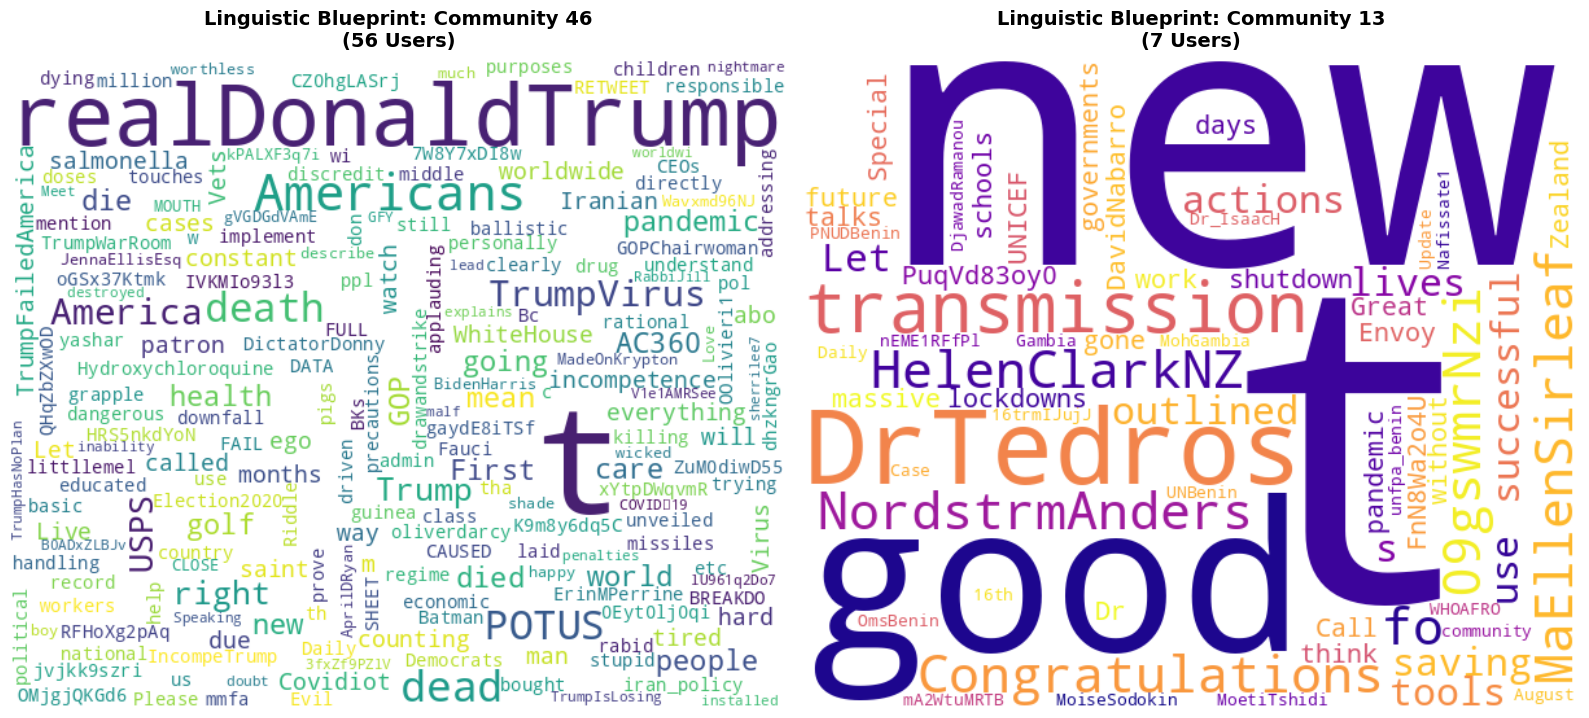

In [41]:
# --- Step 2: Generate and Render Comparative Word Clouds ---

# 1. Initialize WordCloud object for Community A
wordcloud_A = WordCloud(width=600, height=500,
                        background_color='white',
                        stopwords=custom_stopwords,
                        colormap='viridis',
                        random_state=42).generate(text_comm_A)

# 2. Initialize WordCloud object for Community B
wordcloud_B = WordCloud(width=600, height=500,
                        background_color='white',
                        stopwords=custom_stopwords,
                        colormap='plasma',
                        random_state=42).generate(text_comm_B)

# 3. Setup a dual-canvas plotting environment
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Render Community A Cloud
axes[0].imshow(wordcloud_A, interpolation='bilinear')
axes[0].set_title(f"Linguistic Blueprint: Community {largest_comm_ids[0]}\n({active_communities[largest_comm_ids[0]]} Users)",
                  fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')

# Render Community B Cloud
axes[1].imshow(wordcloud_B, interpolation='bilinear')
axes[1].set_title(f"Linguistic Blueprint: Community {largest_comm_ids[1]}\n({active_communities[largest_comm_ids[1]]} Users)",
                  fontsize=14, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Module 7: Network Output 2 — Stakeholder Typology & Audience Mapping

## Classifying Structural Behaviors
Identify "**who is talking to whom**" and "**who is being talked about**".

In any public health crisis or mass communication event, users play vastly different social roles. Some accounts act as massive broadcasting towers, while others form tight-knit conversational safe spaces.

As highlighted in your course curriculum, we can programmatically classify these interaction profiles into an industry-standard **Stakeholder Typology** based on how their incoming vs. outgoing links balance out:

### The 3 Core Communication Frameworks:
1. **Broadcast / Monologue Profile:** Accounts that possess **massive incoming attention** (**high In-Degree**) but rarely mention or reply to anyone else (**low Out-Degree**). Classic examples include news networks (e.g., `@cnn`) or major political leaders. They broadcast information outward in a one-way street.
2. **Dialogue Profile (Engaged Leaders / Mediators):** Accounts that maintain a healthy, **active balance of both incoming and outgoing links**. They listen, reply, mention, and are mentioned back. They serve as vital bridges and network mediators keeping community conversations alive.
3. **Diversified Listeners:** Accounts with low overall individual visibility but a **high spread of outgoing connections**, tracking and engaging with multiple distinct groups across the structural map.
4. **Standard Participant**: This is the "**General Public**". They are the vast majority of the network who might post a tweet and tag one or two people, but they don't have enough sustained interaction to be classified as a leader or broadcaster.

Let's use our NetworkX graph metrics to programmatically filter and tag our users into these precise functional roles!

In [42]:
# --- Step 1: Calculate Degree Profiles & Classify Typologies ---


# 1. Extract In-Degree (how many times a user is mentioned/targeted by others)
in_degrees = dict(G_interaction.in_degree())

# 2. Extract Out-Degree (how many times a user actively mentions/targets others)
out_degrees = dict(G_interaction.out_degree())

# 3. Compile structural profiles into an evaluation DataFrame
df_roles = pd.DataFrame({
    'Username': list(G_interaction.nodes()),
    'In_Degree': [in_degrees[node] for node in G_interaction.nodes()],
    'Out_Degree': [out_degrees[node] for node in G_interaction.nodes()]
})

# 4. Apply programmatic rules to map the exact Stakeholder Typologies
def classify_stakeholder(row):
    # Rule 1: High incoming attention, minimal outward engagement = Broadcaster
    if row['In_Degree'] >= 5 and row['Out_Degree'] <= 1:
        return 'Broadcaster (Monologue)'

    # Rule 2: Active balance of receiving and initiating interactions = Engaged Leader
    elif row['In_Degree'] >= 3 and row['Out_Degree'] >= 2:
        return 'Engaged Leader (Dialogue)'

    # Rule 3: High outward tracking/interaction with lower direct centrality = Diversified Listener
    elif row['Out_Degree'] >= 3 and row['In_Degree'] < 3:
        return 'Diversified Listener'

    # Baseline participant profile
    else:
        return 'Standard Participant'

df_roles['Stakeholder_Role'] = df_roles.apply(classify_stakeholder, axis=1)

# Save roles back into the NetworkX graph nodes as metadata for step 3 visualization
role_dict = pd.Series(df_roles.Stakeholder_Role.values, index=df_roles.Username).to_dict()
nx.set_node_attributes(G_interaction, role_dict, 'stakeholder_role')

print("✅ Stakeholder Typology Categorization Complete!")
print("\n--- Summary Count of Structural Roles Found in Network ---")
print(df_roles['Stakeholder_Role'].value_counts())

✅ Stakeholder Typology Categorization Complete!

--- Summary Count of Structural Roles Found in Network ---
Stakeholder_Role
Standard Participant       1345
Diversified Listener         93
Broadcaster (Monologue)       5
Name: count, dtype: int64


In [43]:
# --- Step 2: Audit Broadcasters and Engaged Leaders ---

# Filter and display the top Broadcasters to show students who is utilizing the Monologue framework
broadcasters_preview = df_roles[df_roles['Stakeholder_Role'] == 'Broadcaster (Monologue)'].sort_values(by='In_Degree', ascending=False)

print("--- Top Identified Broadcasters (Monologue Framework) ---")
print(broadcasters_preview[['Username', 'In_Degree', 'Out_Degree']].head(5))

print("\n" + "="*60 + "\n")

# Filter and display the Engaged Leaders to show who is fueling active Dialogue
leaders_preview = df_roles[df_roles['Stakeholder_Role'] == 'Engaged Leader (Dialogue)'].sort_values(by='In_Degree', ascending=False)

print("--- Top Identified Engaged Leaders (Dialogue Framework) ---")
print(leaders_preview[['Username', 'In_Degree', 'Out_Degree']].head(5))

--- Top Identified Broadcasters (Monologue Framework) ---
            Username  In_Degree  Out_Degree
8    realdonaldtrump         49           0
31               who          7           0
360            potus          6           0
115     borisjohnson          5           0
525              cnn          5           0


--- Top Identified Engaged Leaders (Dialogue Framework) ---
Empty DataFrame
Columns: [Username, In_Degree, Out_Degree]
Index: []


🎨 Rendering Stakeholder Typology Network Visualization Map...


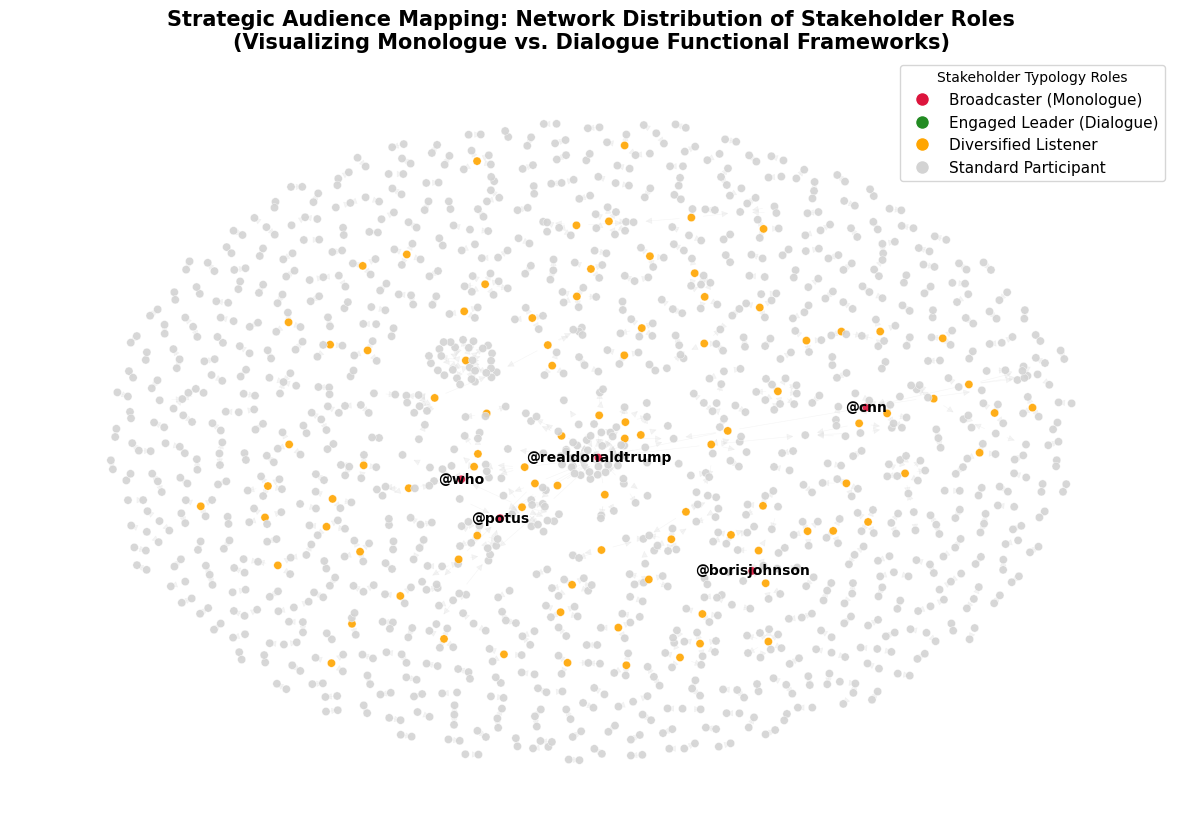

In [44]:
# --- Step 3: Visualizing Stakeholder Typologies Across the Graph ---


# 1. Define a clear, high-contrast color scheme for our stakeholder groups
color_map = {
    'Broadcaster (Monologue)': 'crimson',        # Red targets attention
    'Engaged Leader (Dialogue)': 'forestgreen',   # Green for collaborative hubs
    'Diversified Listener': 'orange',            # Orange for listeners
    'Standard Participant': 'lightgray'          # Gray out the noise
}

# 2. Map colors to each node based on their calculated stakeholder role attribute
graph_node_colors = [color_map[G_interaction.nodes[node]['stakeholder_role']] for node in G_interaction.nodes()]

plt.figure(figsize=(15, 10))

# 3. Use the same spring layout coordinates from Module 5 so the physical shape stays identical
# (This ensures students can see how roles align directly with the positions on the map)
pos = nx.spring_layout(G_interaction, k=0.15, seed=42)

print("🎨 Rendering Stakeholder Typology Network Visualization Map...")

# 4. Draw the structural layout
nx.draw_networkx_nodes(G_interaction, pos, node_size=35,
                       node_color=graph_node_colors, alpha=0.9, edgecolors='white', linewidths=0.3)
nx.draw_networkx_edges(G_interaction, pos, width=0.4, edge_color="gainsboro", alpha=0.3)

# 5. Add text annotations for key targets to tie the visual directly to the data frames
highlight_handles = ['realdonaldtrump', 'who', 'potus', 'borisjohnson', 'cnn']
labels_to_render = {node: f"@{node}" for node in G_interaction.nodes() if node in highlight_handles}
nx.draw_networkx_labels(G_interaction, pos, labels=labels_to_render, font_size=10, font_weight="bold")

# 6. Build a custom legend so students can easily interpret what the colors signify
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=role,
                          markerfacecolor=color, markersize=10) for role, color in color_map.items()]
plt.legend(handles=legend_elements, title="Stakeholder Typology Roles", loc="upper right", fontsize=11)

plt.title("Strategic Audience Mapping: Network Distribution of Stakeholder Roles\n(Visualizing Monologue vs. Dialogue Functional Frameworks)", fontsize=15, fontweight='bold')
plt.axis('off')
plt.show()

# Module 8: Cross-Layering VADER Sentiment by Community

## Blending Structure with Sentiment

Up until this point in today's lab, we have treated **Social Network Analysis (SNA)** and **Natural Language Processing (NLP)** as two entirely separate worlds.

Now, we are going to merge these two layers to achieve **Cross-Layered Network Insights**. We will process our text through the VADER engine to calculate a continuous emotional compound score for every single tweet. Then, we will aggregate those scores across our Louvain community boundaries.

### What this will reveal to you:
This analysis allows us to test if emotional tone is distributed uniformly across society, or if certain digital neighborhoods act as toxic echo chambers while others serve as neutral, fact-sharing clusters.

In [47]:
# --- Step 1: Initialize VADER and Compute Sentiment Scores ---

# We download and initialize NLTK's VADER engine just like we did in our previous labs
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

print("Calculating VADER emotional polarity scores across the network text...")

# Define a quick function to extract the continuous 'compound' score from each tweet row
def get_vader_compound(text):
    return sia.polarity_scores(str(text))['compound']

# Apply the sentiment engine across our core sampled text dataframe
df_sample['VADER_Compound'] = df_sample['text'].apply(get_vader_compound)

# Categorize the continuous compound score into distinct qualitative buckets for clear audience tracking
# Thresholds: Compound >= 0.05 (Positive), Compound <= -0.05 (Negative), otherwise Neutral
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['Sentiment_Class'] = df_sample['VADER_Compound'].apply(categorize_sentiment)

print("✅ Sentiment processing complete! Continuous and categorical fields appended to workspace data frames.")
df_sample[['user_name', 'Community_ID', 'VADER_Compound', 'Sentiment_Class']].head(10)

Calculating VADER emotional polarity scores across the network text...
✅ Sentiment processing complete! Continuous and categorical fields appended to workspace data frames.


,user_name,Community_ID,VADER_Compound,Sentiment_Class
0,British Landlords Association (The BLA),0,0.4926,Positive
1,Mo Eco Devo,-1,0.0361,Neutral
2,KYT,-1,-0.3818,Negative
3,Dr. Wolfgang H Thome,-1,0.0000,Neutral
4,Belinda Hayes,-1,-0.5267,Negative
5,MOHAMMED I. JEGA,-1,0.1027,Positive
6,Propertymark,-1,0.4588,Positive
7,Manish A. Shah,-1,0.6792,Positive
8,WorldStage,-1,0.0000,Neutral
9,The Ismaili,1,0.0258,Neutral


In [48]:
# --- Step 2: Aggregate Sentiment Profiles Across Community Neighborhoods ---

# 1. Filter out the '-1' isolated users so we are analyzing only active conversation networks
df_active_network = df_sample[df_sample['Community_ID'] != -1]

# 2. Identify our top 3 largest active communities to keep our final presentation crisp and clear
top_3_comms = df_active_network['Community_ID'].value_counts().head(3).index.tolist()
df_top_comms = df_active_network[df_active_network['Community_ID'].isin(top_3_comms)]

# 3. Create a crosstabulation matrix showing the distribution percentage of sentiment within each community
sentiment_cross_tab = pd.crosstab(
    df_top_comms['Community_ID'],
    df_top_comms['Sentiment_Class'],
    normalize='index'  # Converts absolute counts to percentages per row
) * 100

print("📈 --- Sentiment Composition Matrix per Discovered Community (%) ---")
print(sentiment_cross_tab.round(2))

📈 --- Sentiment Composition Matrix per Discovered Community (%) ---
Sentiment_Class  Negative  Neutral  Positive
Community_ID                                
13                   0.00    42.86     57.14
46                  46.43    33.93     19.64
56                  14.29    42.86     42.86


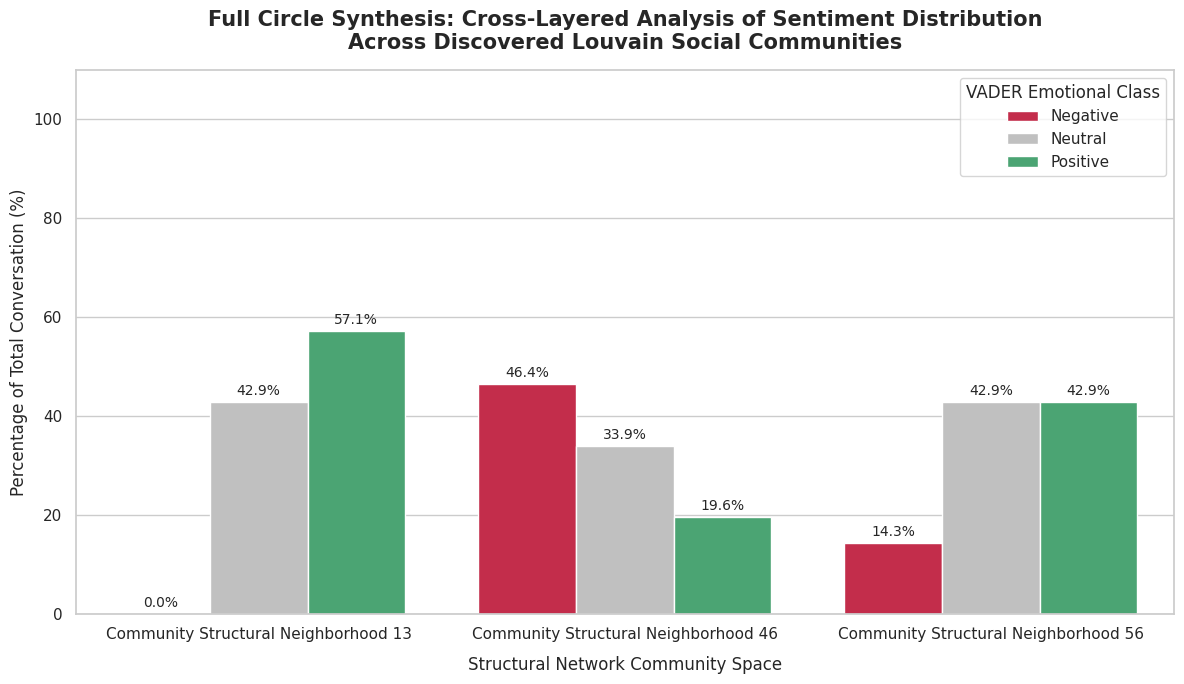

In [49]:
# --- Step 3: Render the Final Full-Circle Synthesis Visualization ---

import seaborn as sns
import matplotlib.pyplot as plt

# Set up visual aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Reshape our cross-tabulation table into a long-form format suitable for Seaborn plotting
df_plot_ready = sentiment_cross_tab.reset_index().melt(
    id_vars='Community_ID',
    var_name='Emotional_Tone',
    value_name='Percentage'
)

# Rename the Community IDs to clear lecture labels so students understand they are looking at distinct neighborhoods
df_plot_ready['Community_Label'] = df_plot_ready['Community_ID'].apply(lambda x: f"Community Structural Neighborhood {x}")

# Draw a grouped bar chart displaying the sentiment distribution patterns side-by-side
ax = sns.barplot(
    data=df_plot_ready,
    x='Community_Label',
    y='Percentage',
    hue='Emotional_Tone',
    palette={'Positive': 'mediumseagreen', 'Neutral': 'silver', 'Negative': 'crimson'}
)

# Annotate values directly on top of the bars so students can clearly read the numerical differences
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.title("Full Circle Synthesis: Cross-Layered Analysis of Sentiment Distribution\nAcross Discovered Louvain Social Communities", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Structural Network Community Space", fontsize=12, labelpad=10)
plt.ylabel("Percentage of Total Conversation (%)", fontsize=12)
plt.ylim(0, 110) # Expand boundary slightly to give room for bar labels
plt.legend(title="VADER Emotional Class", loc="upper right")
plt.tight_layout()
plt.show()